### Proyecto completo de Data Analytics: Python + SQL + Power BI

Dataset TITANIC

Objetivo: entender si hubo un problema en cómo estaban diseñadas las cabinas del Titanic. Para eso, nos gustaría ver si la tasa de supervivencia tiene alguna relación con la clase del pasajero, entre otras caracteristicas de los pasajeros.

In [45]:
# Librerias varias
import pandas as pd
import matplotlib.pyplot as plt

# Configuracion SQL
%load_ext sql

print("Configuracion y librerias ok")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
Configuracion y librerias ok


#### 01. Preparar la data

In [6]:
# caragar la data
df = pd.read_csv("D:/Josefina/Proyectos/Datascience/Data_Analytics/data/Titanic-Dataset.csv")

In [ ]:
# Usar un archivo como SQLite como base de datos
database_filename = 'my_database.db'
df.to_sql('titanic_data', f'sqlite:///{database_filename}', if_exists='replace', index=False)

# Conexion a la base de datos generada
%sql sqlite:///my_database.db

#Configuracion de sql (revisar)
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [ ]:
# Primera consulta, mostrar la data y ver si funciona el sql
%sql SELECT * FROM titanic_data LIMIT 10;

 * sqlite:///my_database.db
Done.


PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,None,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,None,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,None,S
6,0,3,"Moran, Mr. James",male,None,0,0,330877,8.4583,None,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.075,None,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,None,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,None,C


In [ ]:
# Ver que tipo de datos tiene cada columna
# %sql DESCRIBE titanic_data;
%sql PRAGMA table_info(titanic_data);

 * sqlite:///my_database.db
Done.


cid,name,type,notnull,dflt_value,pk
0,PassengerId,BIGINT,0,None,0
1,Survived,BIGINT,0,None,0
2,Pclass,BIGINT,0,None,0
3,Name,TEXT,0,None,0
4,Sex,TEXT,0,None,0
5,Age,FLOAT,0,None,0
6,SibSp,BIGINT,0,None,0
7,Parch,BIGINT,0,None,0
8,Ticket,TEXT,0,None,0
9,Fare,FLOAT,0,None,0


In [ ]:
# Query para filtrar algunas columnas que son las de interes para el proximo analisis
%sql SELECT Survived, Pclass, Age FROM titanic_data LIMIT 10;

 * sqlite:///my_database.db
Done.


Survived,Pclass,Age
0,3,22.0
1,1,38.0
1,3,26.0
1,1,35.0
0,3,35.0
0,3,None
0,1,54.0
0,3,2.0
1,3,27.0
1,2,14.0


In [ ]:
# Contamos cuantos sobrevivientes hay o no
%sql SELECT Survived, COUNT(*) as cantidad FROM titanic_data GROUP BY Survived;


 * sqlite:///my_database.db
Done.


Survived,cantidad
0,549
1,342


In [ ]:
# Contamos cuantos sobrevivientes hay o no
%sql SELECT Age, COUNT(*) as cantidad FROM titanic_data GROUP BY Age;
# Hay bebes, revisar

 * sqlite:///my_database.db
Done.


Age,cantidad
None,177
0.42,1
0.67,1
0.75,2
0.83,2
0.92,1
1.0,7
2.0,10
3.0,6
4.0,10


In [29]:
# Es necesario generar una tabla solo con esa info para trabajar mejor ( con menos info)
#Para eso guardamos esa query como un objeto
data = %sql SELECT Survived, Pclass, Age FROM titanic_data;

#La visualizamos
# print(data)

 * sqlite:///my_database.db
Done.


En este proyecto SQL sirve solo para hacer una primera visualizacion de que datos tengo y seleccionar cuales son interes y poder generar un dataset solo con esa info. De esta forma no se utiliza un dataset muy grande ni tampoco para hacer consultas de limpieza complejas.

Vamos a seguir solo con python ya que es una herramientas mas "facil" y conveniente para trabajar en la limpieza y el modelado de datos.

In [ ]:
# Convertir el objeto de sql (base de datos) en un dataframe
df = pd.DataFrame(data)
print(df.head(10))

   Survived  Pclass   Age
0         0       3  22.0
1         1       1  38.0
2         1       3  26.0
3         1       1  35.0
4         0       3  35.0
5         0       3   NaN
6         0       1  54.0
7         0       3   2.0
8         1       3  27.0
9         1       2  14.0


In [22]:
# Vemos informacion basica del dataframe

print("Informacion basica del dataframe")
print(df.info())

print("---------------------------------------------------")
# Resumen estadistico basico
print("Resumen estadistico basico")
print(df.describe())
print("---------------------------------------------------")

# Numero de NA
print("Numero de NA")
print(df.isnull().sum())

Informacion basica del dataframe
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 21.0 KB
None
---------------------------------------------------
Resumen estadistico basico
         Survived      Pclass         Age
count  891.000000  891.000000  714.000000
mean     0.383838    2.308642   29.699118
std      0.486592    0.836071   14.526497
min      0.000000    1.000000    0.420000
25%      0.000000    2.000000   20.125000
50%      0.000000    3.000000   28.000000
75%      1.000000    3.000000   38.000000
max      1.000000    3.000000   80.000000
---------------------------------------------------
Numero de NA
Survived      0
Pclass        0
Age         177
dtype: int64


Algunos hallazgos:
- La edad es del tipo float y esto en la realidad no deberia ser asi. Para ser mas precisos deberia pasarse a entero
- Hay valores faltantes para la edad, no asi para las otras  dos columnas.
- Hay 3 categorias de pclass.
- Survived solo tiene valor de 0 o 1.
- Se deberia limpiar la columna Age las otras dos columnas parecerian que estan bien.


#### Que hacer con los NA de AGE
 - Media
 - Eliminar
 - Reemplazar por media
 - Otras alternativas

In [ ]:
# Vamos a reemplazar por la media, metodologia muy usada
# Primero calculamos la media
media_age = df ["Age"].mean()

#Reemplazamos
# df ["Age"].fillna(media_age, inplace= True)
df["Age"] = df["Age"].fillna(media_age)


#Verificacion de que no hay mas nulls
print("Valores nulos: ",df["Age"].isnull().sum())

Valores nulos:  0


In [42]:
#Redondeamos datos de la edad
df["Age"] = df["Age"].round()

In [ ]:
# Clasificar a las personas segun su edad en: niños, jovenes, adultos, seniors
#Generamos una nueva columna a traves de una funcion
def categorias_edad(age):
    if age <= 17:
        return 'niños'
    elif 18 <= age <= 25:
        return 'jovenes'
    elif 26 <= age <= 64:
        return 'adultos'
    else:
        return 'Ancianos'

# Crear la nueva columna
df['categorias_edad'] = df['Age'].apply(categorias_edad)

print(df['categorias_edad'].value_counts())

categorias_edad
adultos     579
jovenes     188
niños       113
Ancianos     11
Name: count, dtype: int64


### Algunos plots exploratorios

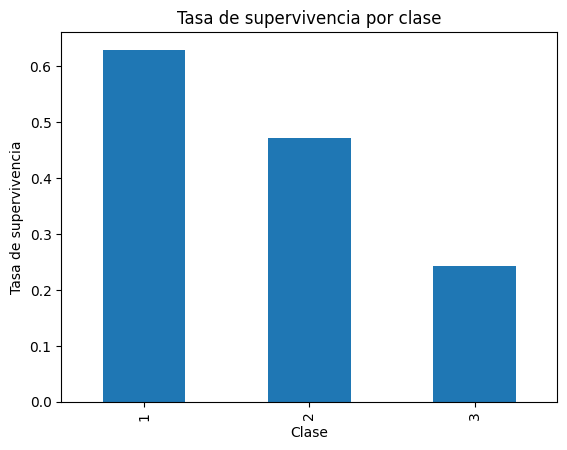

In [ ]:
#Tasa de supervivencia por clase

# Agrupar datos
survival_by_class = df.groupby("Pclass")["Survived"].mean()

# Plot
plt.figure()
survival_by_class.plot(kind="bar")
plt.title("Tasa de supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Tasa de supervivencia")
plt.show()

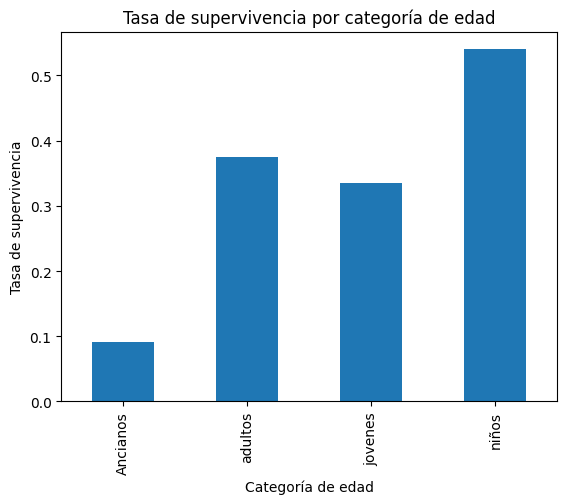

In [48]:
#"Tasa de supervivencia por categoría de edad"
survival_by_age = df.groupby("categorias_edad")["Survived"].mean()

plt.figure()
survival_by_age.plot(kind="bar")
plt.title("Tasa de supervivencia por categoría de edad")
plt.xlabel("Categoría de edad")
plt.ylabel("Tasa de supervivencia")
plt.show()

<Figure size 640x480 with 0 Axes>

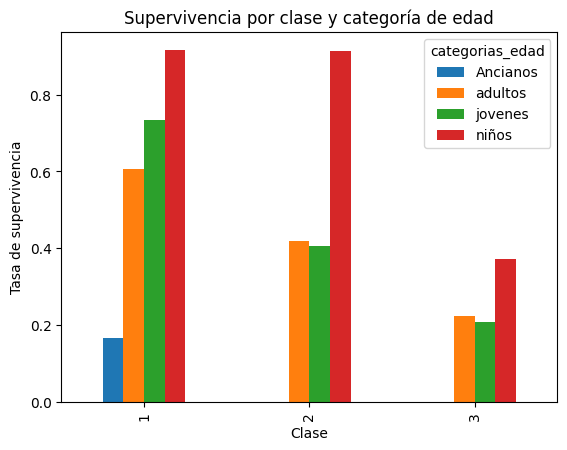

In [50]:
#Supervivencia por clase y categoría de edad
survival_class_age = df.groupby(["Pclass", "categorias_edad"])["Survived"].mean().unstack()

plt.figure()
survival_class_age.plot(kind="bar")
plt.title("Supervivencia por clase y categoría de edad")
plt.xlabel("Clase")
plt.ylabel("Tasa de supervivencia")
plt.show()

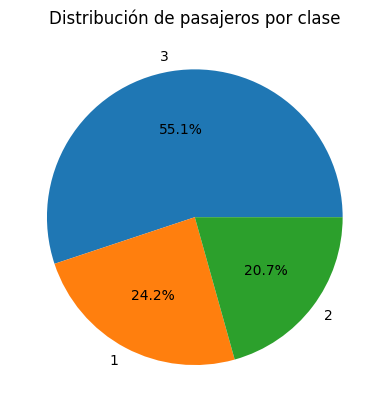

In [51]:
# Distribución de pasajeros por clase
class_counts = df["Pclass"].value_counts()

plt.figure()
class_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribución de pasajeros por clase")
plt.ylabel("")
plt.show()

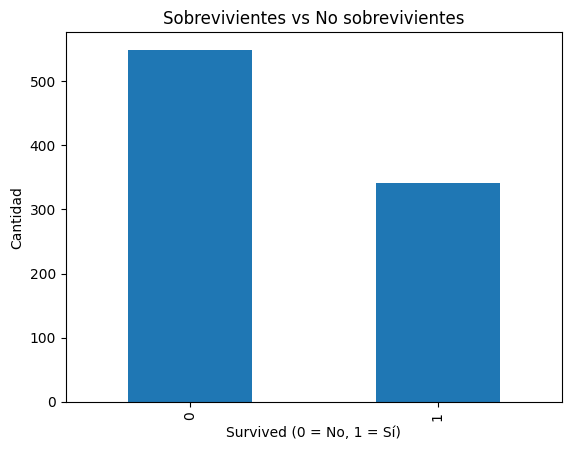

In [52]:
#Sobrevivientes vs No sobreviviente
survived_counts = df["Survived"].value_counts()

plt.figure()
survived_counts.plot(kind="bar")
plt.title("Sobrevivientes vs No sobrevivientes")
plt.xlabel("Survived (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")
plt.show()

In [44]:
# Exportamos datos a csv para trabajarlo en power bi

df.to_csv("df_output.csv", index=False)


# Resumen final
- Objetivo:
Analizar si la tasa de supervivencia tuvo alguna relación con la clase del pasajero. Además, evaluar la edad de los pasajeros dentro de cada clase para identificar grupos etarios más vulnerables.

Análisis:
- Existen diferencias notables en las tasas de supervivencia entre las distintas clases de pasajeros.
- Los pasajeros de primera clase tuvieron casi tres veces más probabilidades de sobrevivir que los de tercera clase. Esto resalta la importancia de analizar los porcentajes de supervivencia y no solo el número total de sobrevivientes. 
- Para los pasajeros de primera clase, la tasa de supervivencia es de aproximadamente un 60%. Sin embargo, al considerar el porcentaje de sobrevivientes dentro de cada clase, este valor resulta aún más relevante, lo que pone en evidencia la necesidad de diferenciar entre tasas globales y tasas específicas por clase.
- La edad también tuvo un papel importante en los resultados de supervivencia. Los niños de segunda clase tuvieron una tasa de supervivencia del 100%, en comparación con el 80% en primera clase y el 40% en tercera clase. No sobrevivieron personas mayores en segunda ni en tercera clase, mientras que solo un 17% (una persona) sobrevivió en primera clase.